# Gram-Type Classification

We build one single conformal envelope trained on true-label NC score vectors:

- For a **gram-neg** phage: NC = raw score (high gram-pos score is surprising for gram-neg)
- For a **gram-pos** phage: NC = 1 − raw score (low gram-pos score is surprising for gram-pos)

After this transformation, both gram types cluster near the origin in NC space, so a single unified envelope is coherent.

### At Testing
For each test phage we create two candidate NC vectors:
1. Scores as-is → hypothesis: gram-neg
2. 1 − scores   → hypothesis: gram-pos

Both, one, or neither may fall inside the envelope, giving prediction sets of size 2, 1, or 0.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

### Loading the Data

In [2]:
SCORES_PATH   = "../../Data/host_type_all_preds.csv"
METADATA_PATH = "../../Data/metadata.csv"
SPLITS_PATH   = "../../Data/all_random_pc_splits.pkl"

print("Loading scores...")
t0 = time.time()
scores_df = pd.read_csv(SCORES_PATH, index_col="proteinID")
print(f"  scores shape : {scores_df.shape}  ({time.time()-t0:.1f}s)")

print("Loading metadata...")
t0 = time.time()
meta_df = pd.read_csv(METADATA_PATH, index_col="proteinID")
meta_df = meta_df[["accession", "host_type", "split"]]
print(f"  metadata shape : {meta_df.shape}  ({time.time()-t0:.1f}s)")

print("Loading protein-cluster splits...")
t0 = time.time()
with open(SPLITS_PATH, "rb") as f:
    pc_splits = pickle.load(f)
# Align splits rows to scores rows — this is critical for correct masking
pc_splits = pc_splits.reindex(scores_df.index)
print(f"  splits shape : {pc_splits.shape}  ({time.time()-t0:.1f}s)")

Loading scores...
  scores shape : (1853074, 40)  (3.1s)
Loading metadata...
  metadata shape : (1853074, 3)  (3.4s)
Loading protein-cluster splits...
  splits shape : (1853074, 2160)  (5.3s)


### Contamination Fix: Protein-Level Masking

`all_random_pc_splits.pkl` records for every protein and every (host, function) model
which fold that protein was in. **Value = 0 means the protein was genuinely held out
(test set) for that model.** Any other value means it was in training — its prediction
is contaminated.

For each gram-type score column `host_type_{func}`, we find all splits columns
ending in `_{func}` (one per host), and mask the protein's score to NaN if it was in
the training set for ANY of those models. This converts contaminated predictions into
missing data, which mean-pooling handles naturally.

In [3]:
score_cols = [c for c in scores_df.columns if c.startswith("host_type_")]

print("Applying protein-level contamination masking...")
t0 = time.time()
scores_masked = scores_df[score_cols].copy()

for col in score_cols:
    func = col.replace("host_type_", "")   # e.g. "lysin"
    matching_split_cols = [c for c in pc_splits.columns if c.endswith("_" + func)]

    if len(matching_split_cols) == 0:
        print(f"  WARNING: no splits columns found for function '{func}' — skipping masking")
        continue

    # is_test = True only if the protein was in split-0 for ALL models using this function
    is_test = (pc_splits[matching_split_cols] == 0).any(axis=1)
    scores_masked[col] = scores_df[col].where(is_test)

print(f"  Done in {time.time()-t0:.1f}s")

# Verification — confirm masking actually did something
original_nans = scores_df[score_cols].isna().sum().sum()
new_nans      = scores_masked.isna().sum().sum()
print(f"  NaNs before masking : {original_nans:,}")
print(f"  NaNs after  masking : {new_nans:,}")
print(f"  Newly masked scores : {new_nans - original_nans:,}")
if new_nans == original_nans:
    print("  WARNING: zero proteins were masked — check function name matching above")

Applying protein-level contamination masking...
  Done in 87.9s
  NaNs before masking : 71,271,481
  NaNs after  masking : 71,324,451
  Newly masked scores : 52,970


### Protein-to-Phage Aggregation (NaN-aware mean pooling)

In [4]:
# Join MASKED scores with metadata — note: scores_masked, not scores_df
combined = scores_masked.join(meta_df, how="inner")

t0 = time.time()
phage_scores = combined.groupby("accession")[score_cols].mean()
phage_meta   = combined.groupby("accession")[["host_type", "split"]].first()
phage_df     = phage_scores.join(phage_meta)
phage_df["split"] = phage_df["split"].astype(int)

print(f"Phage-level shape: {phage_df.shape}  ({time.time()-t0:.1f}s)")
print("\nGram-type distribution:")
print(phage_df["host_type"].value_counts())
print("\nSplit distribution:")
print(phage_df["split"].value_counts().sort_index())

Phage-level shape: (18474, 42)  (0.6s)

Gram-type distribution:
host_type
gram-neg    10735
gram-pos     7708
unknown        31
Name: count, dtype: int64

Split distribution:
split
0    4433
1    3173
2    3646
3    3588
4    3634
Name: count, dtype: int64


### Train / Test Split

In [5]:
# Test set = fold 0. Train set = folds 1-4.
# Contamination is already handled at protein level above, so this split is unbiased.
phage_df["split"] = phage_df["split"].astype(int)
train_all_folds_df = phage_df[phage_df["split"] != 0].copy()
test_df            = phage_df[phage_df["split"] == 0].copy()

train_all_folds_df = train_all_folds_df[train_all_folds_df["host_type"].isin(["gram-neg", "gram-pos"])]
test_df            = test_df[test_df["host_type"].isin(["gram-neg", "gram-pos"])]

print(f"Training phages (folds 1-4) : {len(train_all_folds_df)}")
print(f"Test phages     (fold  0)   : {len(test_df)}")
print(f"\nTrain gram-type distribution:")
print(train_all_folds_df["host_type"].value_counts())
print(f"\nTest gram-type distribution:")
print(test_df["host_type"].value_counts())

Training phages (folds 1-4) : 14021
Test phages     (fold  0)   : 4422

Train gram-type distribution:
host_type
gram-neg    7924
gram-pos    6097
Name: count, dtype: int64

Test gram-type distribution:
host_type
gram-neg    2811
gram-pos    1611
Name: count, dtype: int64


### NaN Handling and Median Imputation

In [6]:
# valid_cols = score_cols
# K = len(valid_cols)
# print(f"Using all {K} score columns")

# # Compute medians from training set ONLY — never touch test set for this
# train_medians = train_all_folds_df[valid_cols].median()
# safe_impute_values = train_medians.copy()
# safe_impute_values[safe_impute_values > 0.6] = 0.5   # cap high medians to neutral

# train_all_folds_df[valid_cols] = train_all_folds_df[valid_cols].fillna(safe_impute_values)
# test_df[valid_cols]            = test_df[valid_cols].fillna(safe_impute_values)

# # Fallback: fill any remaining NaN with 0.5
# train_all_folds_df[valid_cols] = train_all_folds_df[valid_cols].fillna(0.5)
# test_df[valid_cols]            = test_df[valid_cols].fillna(0.5)

# print(f"Residual NaNs — train : {train_all_folds_df[valid_cols].isna().sum().sum()}")
# print(f"Residual NaNs — test  : {test_df[valid_cols].isna().sum().sum()}")

valid_cols = score_cols
K = len(valid_cols)
print(f"Using all {K} score columns")

# 1. Compute global test medians safely first for test set fallback
global_train_medians = train_all_folds_df[valid_cols].median()
global_safe_impute = global_train_medians.copy()
global_safe_impute[global_safe_impute > 0.6] = 0.5

# 2. Impute Training Set conditionally by class to preserve group features
for gt in ["gram-neg", "gram-pos"]:
    mask = train_all_folds_df["host_type"] == gt
    class_medians = train_all_folds_df.loc[mask, valid_cols].median()
    
    # Apply safety cap
    class_safe_impute = class_medians.copy()
    class_safe_impute[class_safe_impute > 0.6] = 0.5
    
    train_all_folds_df.loc[mask, valid_cols] = train_all_folds_df.loc[mask, valid_cols].fillna(class_safe_impute)

# 3. Impute Test Set using global values (since we pretend we don't know test labels)
test_df[valid_cols] = test_df[valid_cols].fillna(global_safe_impute)

# 4. Ultimate Fallback: fill any leftover NaNs with neutral 0.5
train_all_folds_df[valid_cols] = train_all_folds_df[valid_cols].fillna(0.5)
test_df[valid_cols]            = test_df[valid_cols].fillna(0.5)

print(f"Residual NaNs — train : {train_all_folds_df[valid_cols].isna().sum().sum()}")
print(f"Residual NaNs — test  : {test_df[valid_cols].isna().sum().sum()}")

Using all 40 score columns
Residual NaNs — train : 0
Residual NaNs — test  : 0


### Score Characteristics Check

In [7]:
print("Mean score per gram type (averaged across all K columns):")
for gt in ["gram-neg", "gram-pos"]:
    mask = train_all_folds_df["host_type"] == gt
    mean_score   = train_all_folds_df.loc[mask, valid_cols].mean().mean()
    median_score = train_all_folds_df.loc[mask, valid_cols].median().median()
    print(f"  {gt}: mean={mean_score:.4f}, median={median_score:.4f}, n={mask.sum()}")

col_means = pd.DataFrame({
    "gram-neg": train_all_folds_df[train_all_folds_df["host_type"]=="gram-neg"][valid_cols].mean(),
    "gram-pos": train_all_folds_df[train_all_folds_df["host_type"]=="gram-pos"][valid_cols].mean(),
})
col_means["gram-neg > gram-pos"] = col_means["gram-neg"] > col_means["gram-pos"]
print(f"\nColumns where gram-neg scores higher: {col_means['gram-neg > gram-pos'].sum()} / {len(valid_cols)}")

test_raw    = test_df[valid_cols].values
test_labels = test_df["host_type"].values

Mean score per gram type (averaged across all K columns):
  gram-neg: mean=0.0455, median=0.0080, n=7924
  gram-pos: mean=0.7647, median=0.8798, n=6097

Columns where gram-neg scores higher: 0 / 40


### Envelope Methods

In [8]:
def split_data_by_fold(df, valid_cols, test_fold_id):
    df = df.copy()
    df["split"] = df["split"].astype(int)
    
    s1_df = df[df["split"] != test_fold_id]   # ← define these first
    s2_df = df[df["split"] == test_fold_id]

    s1_labels = s1_df["host_type"].to_numpy(dtype=str)
    s2_labels = s2_df["host_type"].to_numpy(dtype=str)

    s1_raw = s1_df[valid_cols].values
    S1_nc  = np.where(s1_labels[:, None] == "gram-neg", s1_raw, 1.0 - s1_raw)

    s2_raw = s2_df[valid_cols].values
    S2_nc  = np.where(s2_labels[:, None] == "gram-neg", s2_raw, 1.0 - s2_raw)

    return S1_nc, S2_nc, s1_labels, s2_labels

In [9]:
def quantile_for_class(tau_scores, labels, cls, alpha):
    vals = np.sort(tau_scores[labels == cls])
    n    = len(vals)
    idx  = int(np.ceil((n + 1) * (1 - alpha))) - 1
    return vals[np.clip(idx, 0, n - 1)]

#### Radial Envelope

In [10]:
def sample_positive_sphere(M, K):
    V = np.abs(np.random.randn(M, K))
    return V / (np.linalg.norm(V, axis=1, keepdims=True) + 1e-12)

# def radial_build_envelope_unbiased(df, valid_cols, fold_id, alpha, M=200, delta_deg=30):
#     S1, S2, labels_S2 = split_data_by_fold(df, valid_cols, fold_id)
#     K = S1.shape[1]
#     U    = sample_positive_sphere(M, K)
#     mags = np.linalg.norm(S1, axis=1)
#     dirs = S1 / (mags[:, None] + 1e-12)
#     cos_thresh = np.cos(np.radians(delta_deg))
#     q_tilde = np.array([
#         np.quantile(mags[(dirs @ U[m]) >= cos_thresh], 1 - alpha)
#         if ((dirs @ U[m]) >= cos_thresh).sum() > 5
#         else np.quantile(mags, 1 - alpha)
#         for m in range(M)
#     ])
#     boundary   = U * q_tilde[:, None]
#     tau_scores = (S2[:, None, :] / (boundary[None, :, :] + 1e-12)).max(axis=2).min(axis=1)
#     t_hat = max(quantile_for_class(tau_scores, labels_S2, "gram-neg", alpha),
#                 quantile_for_class(tau_scores, labels_S2, "gram-pos", alpha))
#     return {"U": U, "q_tilde": q_tilde, "t_hat": t_hat, "method": "radial"}

def radial_build_envelope_unbiased(df, valid_cols, fold_id, alpha, M=200, delta_deg=30):
    S1, S2, _, labels_S2 = split_data_by_fold(df, valid_cols, fold_id)
    K = S1.shape[1]
    U = sample_positive_sphere(M, K)
    mags = np.linalg.norm(S1, axis=1)
    dirs = S1 / (mags[:, None] + 1e-12)
    cos_thresh = np.cos(np.radians(delta_deg))
    
    q_tilde = np.array([
        np.quantile(mags[(dirs @ U[m]) >= cos_thresh], 1 - alpha)
        if ((dirs @ U[m]) >= cos_thresh).sum() > 5
        else np.quantile(mags, 1 - alpha)
        for m in range(M)
    ])
    
    # Calculate tau scores specifically mapped to the base envelope shape
    tau_scores = (S2[:, None, :] / (U * q_tilde[:, None])[None, :, :]).max(axis=2).min(axis=1)
    
    # Calculate separate independent thresholds per class
    t_hat_neg = quantile_for_class(tau_scores, labels_S2, "gram-neg", alpha)
    t_hat_pos = quantile_for_class(tau_scores, labels_S2, "gram-pos", alpha)
    
    # Use the larger t_hat to guarantee coverage across both spaces
    t_hat = max(t_hat_neg, t_hat_pos)
    
    return {"U": U, "q_tilde": q_tilde, "t_hat": t_hat, "method": "radial"}

# def radial_is_in_region(scores, envelope):
#     U, q_tilde, t_hat = envelope["U"], envelope["q_tilde"], envelope["t_hat"]
#     boundary = U * (q_tilde * t_hat)[:, None]
#     return np.any(np.all(scores[:, None, :] <= boundary[None, :, :], axis=2), axis=1)

def radial_is_in_region(scores, envelope):
    U, q_tilde, t_hat = envelope["U"], envelope["q_tilde"], envelope["t_hat"]
    boundary = U * (q_tilde * t_hat)[:, None]
    return np.any(np.all(scores[:, None, :] <= boundary[None, :, :], axis=2), axis=1)

#### Strip Envelope

In [11]:
def strip_shape_discovery(S1, alpha, M):
    N1, K = S1.shape
    bin_edges = np.array([np.linspace(S1[:, j].min(), S1[:, j].max(), M + 1) for j in range(K)])
    limits = np.zeros((K, K, M))
    for j in range(K):
        for m in range(M):
            lo, hi      = bin_edges[j, m], bin_edges[j, m + 1]
            in_strip    = (S1[:, j] >= lo) & (S1[:, j] < hi)
            for i in range(K):
                if i == j: continue
                src = S1[in_strip, i] if in_strip.sum() >= 3 else S1[:, i]
                limits[j, i, m] = np.quantile(src, 1 - alpha)
    # Monotonicity propagation: no holes in the envelope
    for j in range(K):
        for i in range(K):
            if i == j: continue
            for m in range(M - 2, -1, -1):
                limits[j, i, m] = max(limits[j, i, m], limits[j, i, m + 1])
    return bin_edges, limits

def get_bin_indices(scores, bin_edges):
    N, K = scores.shape
    M    = bin_edges.shape[1] - 1
    return np.array([
        np.clip(np.digitize(scores[:, j], bin_edges[j]) - 1, 0, M - 1)
        for j in range(K)
    ]).T

def strip_size_scaling(S2, bin_edges, limits, alpha):
    N2, K  = S2.shape
    bin_idx = get_bin_indices(S2, bin_edges)
    ratios  = np.zeros((N2, K, K))
    for j in range(K):
        for i in range(K):
            if i == j: continue
            lims = limits[j, i, bin_idx[:, j]]
            ratios[:, j, i] = S2[:, i] / (lims + 1e-12)
    return ratios.max(axis=(1, 2))


# def strip_build_envelope_unbiased(df, valid_cols, fold_id, alpha, M=20):
#     S1, S2, labels_S2 = split_data_by_fold(df, valid_cols, fold_id)
#     bin_edges, limits = strip_shape_discovery(S1, alpha, M)
#     tau_scores = strip_size_scaling(S2, bin_edges, limits, alpha)
#     t_hat = max(quantile_for_class(tau_scores, labels_S2, "gram-neg", alpha),
#                 quantile_for_class(tau_scores, labels_S2, "gram-pos", alpha))
#     return {"bin_edges": bin_edges, "limits": limits, "t_hat": t_hat, "method": "strip"}

def strip_build_envelope_unbiased(df, valid_cols, fold_id, alpha, M=20):
    S1, S2, _ , labels_S2 = split_data_by_fold(df, valid_cols, fold_id)
    bin_edges, limits = strip_shape_discovery(S1, alpha, M)
    
    # Scale sizes for cal set
    tau_scores = strip_size_scaling(S2, bin_edges, limits, alpha)
    
    # Calculate class-specific thresholds
    t_hat_neg = quantile_for_class(tau_scores, labels_S2, "gram-neg", alpha)
    t_hat_pos = quantile_for_class(tau_scores, labels_S2, "gram-pos", alpha)
    
    # Pull the defensive maximum envelope boundary threshold
    t_hat = max(t_hat_neg, t_hat_pos)
    
    return {"bin_edges": bin_edges, "limits": limits, "t_hat": t_hat, "method": "strip"}


def strip_is_in_region(scores, envelope):
    bin_edges, limits, t_hat = envelope["bin_edges"], envelope["limits"], envelope["t_hat"]
    N, K = scores.shape
    bin_idx = get_bin_indices(scores, bin_edges)
    
    # Track violation ratios across all pairs of dimensions
    ratios = np.zeros((N, K, K))
    for j in range(K):
        for i in range(K):
            if i == j: continue
            lims = limits[j, i, bin_idx[:, j]]
            ratios[:, j, i] = scores[:, i] / (lims + 1e-12)
            
    # A sample is inside if its maximum violation ratio does not exceed t_hat
    max_ratios = ratios.max(axis=(1, 2))
    return max_ratios <= t_hat

#### Collapsed 1D Envelope

In [12]:
# def collapsed_build_envelope_unbiased(df, valid_cols, fold_id, alpha):
#     S1, S2, labels_S2 = split_data_by_fold(df, valid_cols, fold_id)
#     S1_1d    = S1.mean(axis=1, keepdims=True)
#     S2_1d    = S2.mean(axis=1, keepdims=True)
#     q_tilde  = np.quantile(S1_1d, 1 - alpha)
#     tau_scores = (S2_1d / (q_tilde + 1e-12)).ravel()
#     t_hat = max(quantile_for_class(tau_scores, labels_S2, "gram-neg", alpha),
#                 quantile_for_class(tau_scores, labels_S2, "gram-pos", alpha))
#     return {"q_tilde": q_tilde, "t_hat": t_hat, "method": "collapsed"}

def collapsed_build_envelope_unbiased(df, valid_cols, fold_id, alpha):
    S1, S2, _ , labels_S2 = split_data_by_fold(df, valid_cols, fold_id)
    S1_1d = S1.mean(axis=1, keepdims=True)
    S2_1d = S2.mean(axis=1, keepdims=True)
    
    q_tilde = np.quantile(S1_1d, 1 - alpha)
    tau_scores = (S2_1d / (q_tilde + 1e-12)).ravel()
    
    # Individual class quantiles
    t_hat_neg = quantile_for_class(tau_scores, labels_S2, "gram-neg", alpha)
    t_hat_pos = quantile_for_class(tau_scores, labels_S2, "gram-pos", alpha)
    
    t_hat = max(t_hat_neg, t_hat_pos)
    
    return {"q_tilde": q_tilde, "t_hat": t_hat, "method": "collapsed"}

def collapsed_is_in_region(scores, envelope):
    scores_1d = scores.mean(axis=1, keepdims=True)
    return (scores_1d.ravel() <= envelope["q_tilde"] * envelope["t_hat"])

In [13]:
def is_in_region(scores, envelope):
    if envelope["method"] == "radial":
        return radial_is_in_region(scores, envelope)
    elif envelope["method"] == "strip":
        return strip_is_in_region(scores, envelope)
    else:
        return collapsed_is_in_region(scores, envelope)

### Prediction

In [14]:
def predict_gram_type_nc(test_raw, envelope, gamma):
    nc_gramneg = test_raw
    nc_grampos = (1.0 - test_raw) * gamma

    in_gramneg = is_in_region(nc_gramneg, envelope)
    in_grampos = is_in_region(nc_grampos, envelope)

    results = []
    for i in range(len(test_raw)):
        pred_set = []
        if in_gramneg[i]: pred_set.append("gram-neg")
        if in_grampos[i]: pred_set.append("gram-pos")
        results.append({
            "in_gramneg"     : bool(in_gramneg[i]),
            "in_grampos"     : bool(in_grampos[i]),
            "prediction_set" : pred_set
        })
    return results

### Evaluation

In [15]:
def evaluate(results, true_labels, method_name, alpha, verbose=True):
    n         = len(results)
    set_sizes = [len(r["prediction_set"]) for r in results]
    covered   = sum(true_labels[i] in r["prediction_set"] for i, r in enumerate(results))
    singletons        = [(r, true_labels[i]) for i, r in enumerate(results) if len(r["prediction_set"]) == 1]
    correct_singletons = sum(r["prediction_set"][0] == lbl for r, lbl in singletons)
    empty  = sum(s == 0 for s in set_sizes)
    size2  = sum(s == 2 for s in set_sizes)
    if verbose:
        print(f"\n{'='*55}")
        print(f" {method_name.upper()} — {n} test phages | alpha={alpha}")
        print(f" Coverage : {covered/n:.3f}  (target >= {1-alpha:.2f})")
        print(f"{'='*55}")
    return {
        "coverage"          : covered / n,
        "avg_set_size"      : np.mean(set_sizes),
        "empty_rate"        : empty / n,
        "singleton_rate"    : len(singletons) / n,
        "size2_rate"        : size2 / n,
        "singleton_accuracy": correct_singletons / len(singletons) if singletons else None,
        "set_sizes"         : set_sizes,
        "per_type_coverage" : {
            gt: sum(true_labels[i] in results[i]["prediction_set"]
                    for i in range(n) if true_labels[i] == gt)
               / max(1, sum(lbl == gt for lbl in true_labels))
            for gt in ["gram-neg", "gram-pos"]
        },
    }

### Main Evaluation Loop

In [ ]:
# def run_builder_with_scaling(builder_func, *args, **kwargs):
#     original_split = split_data_by_fold
#     globals()['split_data_by_fold'] = lambda df, cols, fid: (S1_scaled, S2_scaled, labels_S1, labels_S2)
#     try:
#         env = builder_func(*args, **kwargs)
#     finally:
#         globals()['split_data_by_fold'] = original_split
#     return env

# r_env = run_builder_with_scaling(radial_build_envelope_unbiased, train_all_folds_df, valid_cols, fold_id, alpha, M=200, delta_deg=30)
# s_env = run_builder_with_scaling(strip_build_envelope_unbiased, train_all_folds_df, valid_cols, fold_id, alpha, M=20)
# c_env = run_builder_with_scaling(collapsed_build_envelope_unbiased, train_all_folds_df, valid_cols, fold_id, alpha)

NameError: name 'fold_id' is not defined

In [ ]:
# # =====================================================================
# # 10. MAIN EVALUATION LOOP WITH BALANCED SCALING
# # =====================================================================

# available_folds = [1, 2, 3, 4]
# all_metrics     = {"radial": [], "strip": [], "collapsed": []}
# alpha           = 0.1

# print(f"Running {len(available_folds)} folds  |  alpha = {alpha}")
# for fold_id in available_folds:
    
#     # 1. Unpack fold configurations completely using fold_id
#     S1, S2, labels_S1, labels_S2 = split_data_by_fold(train_all_folds_df, valid_cols, fold_id)
    
#     # 2. --- DYNAMIC VARIANCE ADJUSTMENT ---
#     # Compute baseline distance configurations across both clusters on S1
#     mad_neg = np.median(np.linalg.norm(S1[labels_S1 == "gram-neg"], axis=1)) if "gram-neg" in labels_S1 else 1.0
#     mad_pos = np.median(np.linalg.norm(S1[labels_S1 == "gram-pos"], axis=1)) if "gram-pos" in labels_S1 else 1.0
    
#     # Derive the scaling ratio mapping
#     gamma = mad_neg / (mad_pos + 1e-12)
    
#     # Compress high variance clusters to establish distribution symmetry
#     S1_scaled = S1.copy()
#     S2_scaled = S2.copy()
#     S1_scaled[labels_S1 == "gram-pos"] *= gamma
#     S2_scaled[labels_S2 == "gram-pos"] *= gamma
    
#     # Interceptor wrapper function to pass scaled matrices to builders without modifying their signatures
#     def run_builder_with_scaling(builder_func, *args, **kwargs):
#         original_split = split_data_by_fold
#         globals()['split_data_by_fold'] = lambda df, cols, fid: (S1_scaled, S2_scaled, labels_S1, labels_S2)
#         try:
#             env = builder_func(*args, **kwargs)
#         finally:
#             globals()['split_data_by_fold'] = original_split
#         return env

#     # 3. Build single envelopes using the scaled arrays
#     r_env = run_builder_with_scaling(radial_build_envelope_unbiased, train_all_folds_df, valid_cols, fold_id, alpha, M=200, delta_deg=30)
#     s_env = run_builder_with_scaling(strip_build_envelope_unbiased, train_all_folds_df, valid_cols, fold_id, alpha, M=20)
#     c_env = run_builder_with_scaling(collapsed_build_envelope_unbiased, train_all_folds_df, valid_cols, fold_id, alpha)

# # 4. Predict on current fold validation data (S2), matching vectors to training scale
#     r_res = predict_gram_type_nc(S2, r_env, gamma)
#     s_res = predict_gram_type_nc(S2, s_env, gamma)
#     c_res = predict_gram_type_nc(S2, c_env, gamma)

#     for key, res in [("radial", r_res), ("strip", s_res), ("collapsed", c_res)]:
#         all_metrics[key].append(evaluate(res, test_labels, key, alpha, verbose=False))

#     print(f"  Fold {fold_id} complete  |  "
#           f"radial cov={all_metrics['radial'][-1]['coverage']:.3f}  "
#           f"strip cov={all_metrics['strip'][-1]['coverage']:.3f}  "
#           f"collapsed cov={all_metrics['collapsed'][-1]['coverage']:.3f}")

Running 4 folds  |  alpha = 0.1


NameError: name 'predict_gram_type_nc_scaled' is not defined

In [18]:
# =====================================================================
# 10. MAIN EVALUATION LOOP WITH BALANCED SCALING (FIXED)
# =====================================================================

available_folds = [1, 2, 3, 4]
all_metrics     = {"radial": [], "strip": [], "collapsed": []}
alpha           = 0.1

print(f"Running {len(available_folds)} folds  |  alpha = {alpha}")

for fold_id in available_folds:
    
    # 1. Unpack fold configurations completely using fold_id
    S1, S2, labels_S1, labels_S2 = split_data_by_fold(train_all_folds_df, valid_cols, fold_id)
    
    # 2. --- DYNAMIC VARIANCE ADJUSTMENT ---
    # Compute baseline distance configurations across both clusters on S1
    mad_neg = np.median(np.linalg.norm(S1[labels_S1 == "gram-neg"], axis=1)) if "gram-neg" in labels_S1 else 1.0
    mad_pos = np.median(np.linalg.norm(S1[labels_S1 == "gram-pos"], axis=1)) if "gram-pos" in labels_S1 else 1.0
    
    # Derive the scaling ratio mapping
    gamma = mad_neg / (mad_pos + 1e-12)
    
    # Compress high variance clusters to establish distribution symmetry
    S1_scaled = S1.copy()
    S2_scaled = S2.copy()
    S1_scaled[labels_S1 == "gram-pos"] *= gamma
    S2_scaled[labels_S2 == "gram-pos"] *= gamma
    
    # Interceptor wrapper function to pass scaled matrices to builders
    def run_builder_with_scaling(builder_func, *args, **kwargs):
        original_split = split_data_by_fold
        globals()['split_data_by_fold'] = lambda df, cols, fid: (S1_scaled, S2_scaled, labels_S1, labels_S2)
        try:
            env = builder_func(*args, **kwargs)
        finally:
            globals()['split_data_by_fold'] = original_split
        return env

    # 3. Build single envelopes using the scaled arrays
    r_env = run_builder_with_scaling(radial_build_envelope_unbiased, train_all_folds_df, valid_cols, fold_id, alpha, M=200, delta_deg=30)
    s_env = run_builder_with_scaling(strip_build_envelope_unbiased, train_all_folds_df, valid_cols, fold_id, alpha, M=20)
    c_env = run_builder_with_scaling(collapsed_build_envelope_unbiased, train_all_folds_df, valid_cols, fold_id, alpha)

    # 4. FIXED: Predict on current fold validation data (S2), calling the correct function
    r_res = predict_gram_type_nc(S2, r_env, gamma)
    s_res = predict_gram_type_nc(S2, s_env, gamma)
    c_res = predict_gram_type_nc(S2, c_env, gamma)

    # 5. FIXED: Evaluate against labels_S2 (validation labels) instead of test_labels
    for key, res in [("radial", r_res), ("strip", s_res), ("collapsed", c_res)]:     all_metrics[key].append(evaluate(res, labels_S2, key, alpha, verbose=False))

    print(f"  Fold {fold_id} complete  |  "
          f"radial cov={all_metrics['radial'][-1]['coverage']:.3f}  "
          f"strip cov={all_metrics['strip'][-1]['coverage']:.3f}  "
          f"collapsed cov={all_metrics['collapsed'][-1]['coverage']:.3f}")

Running 4 folds  |  alpha = 0.1
  Fold 1 complete  |  radial cov=0.504  strip cov=0.500  collapsed cov=0.499
  Fold 2 complete  |  radial cov=0.526  strip cov=0.576  collapsed cov=0.526
  Fold 3 complete  |  radial cov=0.473  strip cov=0.510  collapsed cov=0.472
  Fold 4 complete  |  radial cov=0.544  strip cov=0.538  collapsed cov=0.538


### Summary Table

In [19]:
methods_names = ["Radial", "Strip", "Collapsed 1D"]
method_keys   = ["radial", "strip", "collapsed"]

print(f"\n{'='*65}")
print(f" SUMMARY ACROSS FOLDS 1-4  (alpha={alpha})")
print(f"{'='*65}")
for name, key in zip(methods_names, method_keys):
    runs    = all_metrics[key]
    cov     = np.array([m["coverage"]                       for m in runs])
    cov_neg = np.array([m["per_type_coverage"]["gram-neg"]  for m in runs])
    cov_pos = np.array([m["per_type_coverage"]["gram-pos"]  for m in runs])
    avg_sz  = np.array([m["avg_set_size"]                   for m in runs])
    sing_ac = np.array([m["singleton_accuracy"] for m in runs if m["singleton_accuracy"] is not None])
    print(f"\n  {name}")
    print(f"    Overall coverage  : {cov.mean():.3f} ± {cov.std():.3f}  (target >= {1-alpha:.2f})")
    print(f"    gram-neg coverage : {cov_neg.mean():.3f} ± {cov_neg.std():.3f}")
    print(f"    gram-pos coverage : {cov_pos.mean():.3f} ± {cov_pos.std():.3f}")
    print(f"    Avg set size      : {avg_sz.mean():.3f} ± {avg_sz.std():.3f}")
    if len(sing_ac):
        print(f"    Singleton acc.    : {sing_ac.mean():.3f} ± {sing_ac.std():.3f}")

rows = []
for name, key in zip(methods_names, method_keys):
    runs    = all_metrics[key]
    cov     = np.array([m["coverage"]                      for m in runs])
    cov_neg = np.array([m["per_type_coverage"]["gram-neg"] for m in runs])
    cov_pos = np.array([m["per_type_coverage"]["gram-pos"] for m in runs])
    avg_sz  = np.array([m["avg_set_size"]                  for m in runs])
    empty   = np.array([m["empty_rate"]                    for m in runs])
    size2   = np.array([m["size2_rate"]                    for m in runs])
    sing_ac = np.array([m["singleton_accuracy"] for m in runs if m["singleton_accuracy"] is not None])
    rows.append({
        "Method"        : name,
        "Coverage"      : f"{cov.mean():.3f}±{cov.std():.3f}",
        "Neg coverage"  : f"{cov_neg.mean():.3f}±{cov_neg.std():.3f}",
        "Pos coverage"  : f"{cov_pos.mean():.3f}±{cov_pos.std():.3f}",
        "Avg set size"  : f"{avg_sz.mean():.3f}±{avg_sz.std():.3f}",
        "Empty %"       : f"{empty.mean()*100:.1f}±{empty.std()*100:.1f}",
        "Size-2 %"      : f"{size2.mean()*100:.1f}±{size2.std()*100:.1f}",
        "Singleton acc.": f"{sing_ac.mean():.3f}±{sing_ac.std():.3f}" if len(sing_ac) else "N/A",
    })
summary_df = pd.DataFrame(rows)
print("\n", summary_df.to_string(index=False))


 SUMMARY ACROSS FOLDS 1-4  (alpha=0.1)

  Radial
    Overall coverage  : 0.512 ± 0.026  (target >= 0.90)
    gram-neg coverage : 0.902 ± 0.003
    gram-pos coverage : 0.005 ± 0.005
    Avg set size      : 0.512 ± 0.027
    Singleton acc.    : 0.999 ± 0.001

  Strip
    Overall coverage  : 0.531 ± 0.029  (target >= 0.90)
    gram-neg coverage : 0.940 ± 0.040
    gram-pos coverage : 0.001 ± 0.001
    Avg set size      : 0.635 ± 0.104
    Singleton acc.    : 0.852 ± 0.096

  Collapsed 1D
    Overall coverage  : 0.509 ± 0.025  (target >= 0.90)
    gram-neg coverage : 0.900 ± 0.000
    gram-pos coverage : 0.001 ± 0.000
    Avg set size      : 0.509 ± 0.026
    Singleton acc.    : 0.999 ± 0.001

       Method    Coverage Neg coverage Pos coverage Avg set size   Empty % Size-2 % Singleton acc.
      Radial 0.512±0.026  0.902±0.003  0.005±0.005  0.512±0.027  48.8±2.7  0.0±0.0    0.999±0.001
       Strip 0.531±0.029  0.940±0.040  0.001±0.001  0.635±0.104 36.5±10.4  0.0±0.0    0.852±0.096
Colla

### Comparison Plots

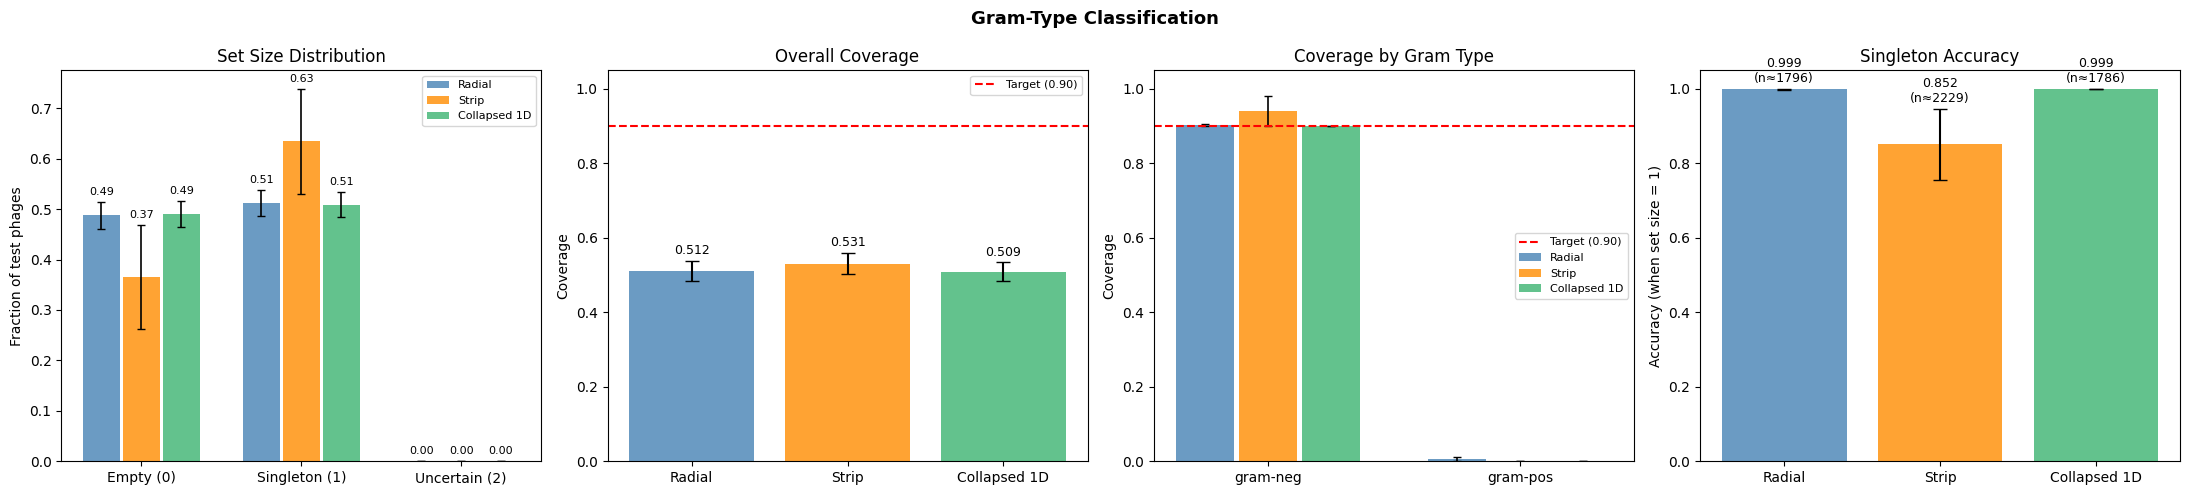

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
colors = ["steelblue", "darkorange", "mediumseagreen"]

# Plot 1: Set size distribution
ax = axes[0]
x  = np.array([0, 1, 2])
offsets = [-0.25, 0.0, 0.25]
for name, key, c, offset in zip(methods_names, method_keys, colors, offsets):
    means, stds = [], []
    for s in [0, 1, 2]:
        fracs = np.array([
            sum(1 for sz in m["set_sizes"] if sz == s) / len(m["set_sizes"])
            for m in all_metrics[key]
        ])
        means.append(fracs.mean()); stds.append(fracs.std())
    bars = ax.bar(x + offset, means, width=0.23, label=name, color=c, alpha=0.8)
    ax.errorbar(x + offset, means, yerr=stds, fmt="none", color="black", capsize=3, linewidth=1.2)
    for rect, val, std in zip(bars, means, stds):
        ax.text(rect.get_x() + rect.get_width()/2, val + std + 0.01, f"{val:.2f}",
                ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(["Empty (0)", "Singleton (1)", "Uncertain (2)"])
ax.set_title("Set Size Distribution"); ax.set_ylabel("Fraction of test phages"); ax.legend(fontsize=8)

# Plot 2: Overall coverage
ax    = axes[1]
means = [np.mean([m["coverage"] for m in all_metrics[k]]) for k in method_keys]
stds  = [np.std ([m["coverage"] for m in all_metrics[k]]) for k in method_keys]
bars  = ax.bar(methods_names, means, color=colors, alpha=0.8)
ax.errorbar(range(len(methods_names)), means, yerr=stds, fmt="none", color="black", capsize=5, linewidth=1.5)
ax.axhline(1 - alpha, color="red", linestyle="--", label=f"Target ({1-alpha:.2f})")
ax.set_ylim(0, 1.05); ax.set_title("Overall Coverage"); ax.set_ylabel("Coverage"); ax.legend(fontsize=8)
for bar, val, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, val + std + 0.01, f"{val:.3f}",
            ha="center", va="bottom", fontsize=9)

# Plot 3: Per-class coverage
ax       = axes[2]
gram_types = ["gram-neg", "gram-pos"]
x        = np.arange(len(gram_types))
for name, key, c, offset in zip(methods_names, method_keys, colors, offsets):
    means = [np.mean([m["per_type_coverage"][gt] for m in all_metrics[key]]) for gt in gram_types]
    stds  = [np.std ([m["per_type_coverage"][gt] for m in all_metrics[key]]) for gt in gram_types]
    ax.bar(x + offset, means, width=0.23, label=name, color=c, alpha=0.8)
    ax.errorbar(x + offset, means, yerr=stds, fmt="none", color="black", capsize=3, linewidth=1.2)
ax.axhline(1 - alpha, color="red", linestyle="--", label=f"Target ({1-alpha:.2f})")
ax.set_xticks(x); ax.set_xticklabels(gram_types)
ax.set_ylim(0, 1.05); ax.set_title("Coverage by Gram Type"); ax.set_ylabel("Coverage"); ax.legend(fontsize=8)

# Plot 4: Singleton accuracy
ax    = axes[3]
means, stds, ns = [], [], []
for key in method_keys:
    vals = np.array([m["singleton_accuracy"] for m in all_metrics[key] if m["singleton_accuracy"] is not None])
    means.append(vals.mean() if len(vals) else 0)
    stds.append (vals.std()  if len(vals) else 0)
    ns.append(int(np.mean([m["singleton_rate"] * len(m["set_sizes"]) for m in all_metrics[key]])))
bars = ax.bar(methods_names, means, color=colors, alpha=0.8)
ax.errorbar(range(len(methods_names)), means, yerr=stds, fmt="none", color="black", capsize=5, linewidth=1.5)
ax.set_ylim(0, 1.05); ax.set_title("Singleton Accuracy"); ax.set_ylabel("Accuracy (when set size = 1)")
for bar, val, std, n_s in zip(bars, means, stds, ns):
    ax.text(bar.get_x() + bar.get_width()/2, val + std + 0.01, f"{val:.3f}\n(n≈{n_s})",
            ha="center", va="bottom", fontsize=9)

plt.suptitle("Gram-Type Classification", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()